<a href="https://colab.research.google.com/github/enzoura07/Teoria-do-aprendizado-estatisco/blob/main/reg_linear_ridge_e_lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dados filtrados com sucesso! Total de observacoes validas: 81448 

===== PREVISOES DO MODELO ORIGINAL (MQO, ajustado em todos os dados) =====
  ESCOLARIDADE_ANOS  ANO      SEXO IDADE_PREVISTA
1               0.0 2023 Masculino           72.8
2               5.5 2023 Masculino           67.3
3              12.0 2023  Feminino           67.2

===== COMPARACAO MQO x RIDGE x LASSO (regressao linear) =====
              Modelo RMSE_treino RMSE_teste
1                MQO       16.81      16.79
2 Ridge (lambda.min)       16.81      16.79
3 Lasso (lambda.1se)       16.87      16.83

===== COEFICIENTES: MQO =====
      (Intercept) ESCOLARIDADE_ANOS               ANO     SEXOMasculino 
        -419.7372           -0.9914            0.2466           -6.5469 

===== COEFICIENTES: RIDGE (lambda.min) =====
                  lambda.min
(Intercept)        -409.5926
ESCOLARIDADE_ANOS    -0.9714
ANO                   0.2415
SEXOMasculino        -6.4185

===== COEFICIENTES: LASSO (lambda.1se) =====
     

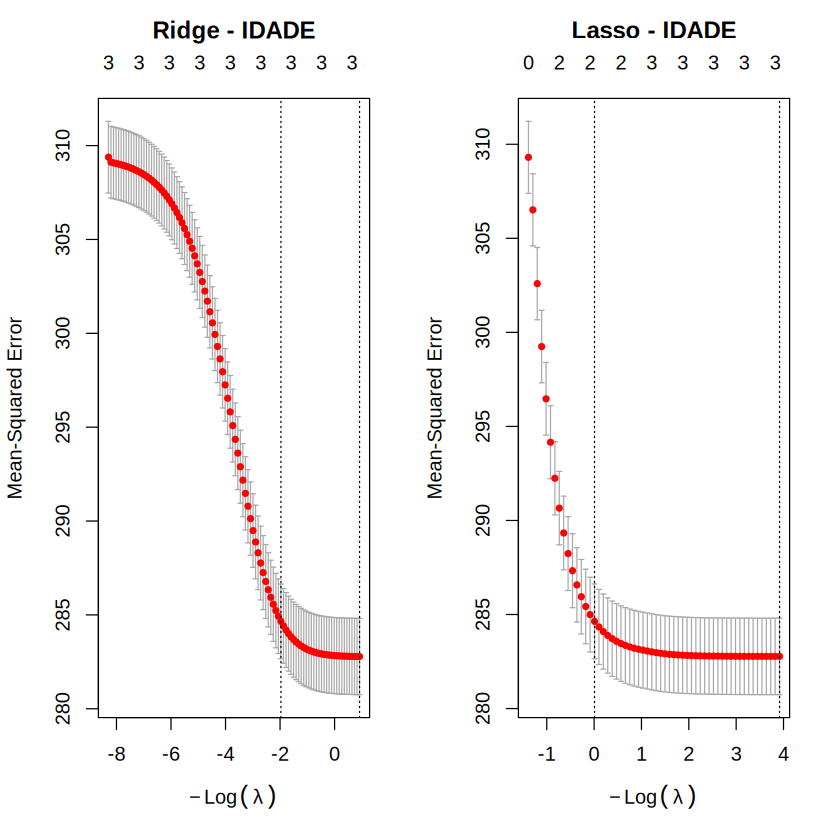

In [6]:


# Regressao Linear - IDADE ~ ESCOLARIDADE_ANOS + ANO + SEXO


# 0) Instalacao e carregamento seguro dos pacotes

if (!require("glmnet", quietly = TRUE)) install.packages("glmnet", repos = "https://cloud.r-project.org/")
if (!require("readxl", quietly = TRUE)) install.packages("readxl", repos = "https://cloud.r-project.org/")

library(glmnet)
library(readxl)


# 1) Leitura flexivel e preparo dos dados

# Detecta automaticamente se está no Colab (/content/) ou no RStudio local
caminho_arquivo <- if (file.exists("/content/datasetDEF_translated.xlsx")) {
  "/content/datasetDEF_translated.xlsx"
} else if (file.exists("datasetDEF_translated.xlsx")) {
  "datasetDEF_translated.xlsx"
} else {
  stop("ERRO: O arquivo 'datasetDEF_translated.xlsx' nao foi encontrado!\nFaça o upload do arquivo Excel antes de rodar o codigo.")
}

dados <- read_excel(caminho_arquivo)

dados$IDADE <- as.numeric(dados$IDADE)

mapa_escolaridade <- c(
  "Nenhuma" = 0,
  "1 a 3 anos" = 2,
  "4 a 7 anos" = 5.5,
  "8 a 11 anos" = 9.5,
  "12 anos ou mais" = 12
)

dados$ESCOLARIDADE_ANOS <- mapa_escolaridade[dados$ESCOLARIDADE]

dados$SEXO <- factor(
  dados$SEXO,
  levels = c("Feminino", "Masculino")
)

dados_reg <- dados[
  !is.na(dados$ESCOLARIDADE_ANOS) &
  !is.na(dados$IDADE) &
  !is.na(dados$ANO) &
  !is.na(dados$SEXO),
]

# Verificacao de seguranca
if (nrow(dados_reg) == 0) {
  stop("ERRO: O conjunto de dados apos o filtro ficou vazio! Verifique as categorias da coluna ESCOLARIDADE.")
}

cat("Dados filtrados com sucesso! Total de observacoes validas:", nrow(dados_reg), "\n")


# 2) Modelo original (MQO), ajustado em todos os dados

m2 <- lm(
  IDADE ~ ESCOLARIDADE_ANOS + ANO + SEXO,
  data = dados_reg
)

novos_dados <- data.frame(
  ESCOLARIDADE_ANOS = c(0, 5.5, 12),
  ANO = c(2023, 2023, 2023),
  SEXO = factor(
    c("Masculino", "Masculino", "Feminino"),
    levels = c("Feminino", "Masculino")
  )
)

previsoes <- predict(m2, novos_dados)

cat("\n===== PREVISOES DO MODELO ORIGINAL (MQO, ajustado em todos os dados) =====\n")
print(data.frame(
  novos_dados,
  IDADE_PREVISTA = round(previsoes, 1)
))


# 3) Divisao treino/teste (70/30) para comparacao MQO x Ridge x Lasso

rmse <- function(pred, obs) sqrt(mean((pred - obs)^2))

set.seed(42)
n <- nrow(dados_reg)
idx_treino <- sample(seq_len(n), size = round(0.7 * n))
treino <- dados_reg[idx_treino, ]
teste  <- dados_reg[-idx_treino, ]

m_mqo_cv <- lm(IDADE ~ ESCOLARIDADE_ANOS + ANO + SEXO, data = treino)

rmse_mqo_treino <- rmse(predict(m_mqo_cv, treino), treino$IDADE)
rmse_mqo_teste  <- rmse(predict(m_mqo_cv, teste),  teste$IDADE)


# 4) Matrizes para o glmnet (Ridge e Lasso trabalham com matriz)

X_treino <- model.matrix(IDADE ~ ESCOLARIDADE_ANOS + ANO + SEXO, data = treino)[, -1]
y_treino <- treino$IDADE
X_teste  <- model.matrix(IDADE ~ ESCOLARIDADE_ANOS + ANO + SEXO, data = teste)[, -1]
y_teste  <- teste$IDADE


# 5) Ridge (alpha = 0) e Lasso (alpha = 1) - lambda escolhido por CV

set.seed(1)
cv_ridge <- cv.glmnet(X_treino, y_treino, alpha = 0)
set.seed(1)
cv_lasso <- cv.glmnet(X_treino, y_treino, alpha = 1)

rmse_ridge_treino <- rmse(as.vector(predict(cv_ridge, X_treino, s = "lambda.min")), y_treino)
rmse_ridge_teste  <- rmse(as.vector(predict(cv_ridge, X_teste,  s = "lambda.min")), y_teste)

rmse_lasso_treino <- rmse(as.vector(predict(cv_lasso, X_treino, s = "lambda.1se")), y_treino)
rmse_lasso_teste  <- rmse(as.vector(predict(cv_lasso, X_teste,  s = "lambda.1se")), y_teste)


# 6) Tabela comparativa: MQO x Ridge x Lasso

comparacao <- data.frame(
  Modelo      = c("MQO", "Ridge (lambda.min)", "Lasso (lambda.1se)"),
  RMSE_treino = round(c(rmse_mqo_treino, rmse_ridge_treino, rmse_lasso_treino), 2),
  RMSE_teste  = round(c(rmse_mqo_teste,  rmse_ridge_teste,  rmse_lasso_teste), 2)
)

cat("\n===== COMPARACAO MQO x RIDGE x LASSO (regressao linear) =====\n")
print(comparacao)


# 7) Coeficientes lado a lado

cat("\n===== COEFICIENTES: MQO =====\n")
print(round(coef(m_mqo_cv), 4))

cat("\n===== COEFICIENTES: RIDGE (lambda.min) =====\n")
print(round(as.matrix(coef(cv_ridge, s = "lambda.min")), 4))

cat("\n===== COEFICIENTES: LASSO (lambda.1se) =====\n")
print(round(as.matrix(coef(cv_lasso, s = "lambda.1se")), 4))

cat("\nlambda.min (Ridge):", round(cv_ridge$lambda.min, 4), "\n")
cat("lambda.min (Lasso):", round(cv_lasso$lambda.min, 4),
    "| lambda.1se (Lasso):", round(cv_lasso$lambda.1se, 4), "\n")


# 8) Curvas de validacao cruzada

par(mfrow = c(1, 2))
plot(cv_ridge); title("Ridge - IDADE", line = 2.5)
plot(cv_lasso); title("Lasso - IDADE", line = 2.5)